# Trader Performance vs Market Sentiment



In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [21]:

# laoding data
df = pd.read_csv("fear_greed_index.csv")
df1 = pd.read_csv("historical_data.csv")

# clearing columns
df.columns = df.columns.str.lower().str.strip()
df1.columns = df1.columns.str.lower().str.strip()


In [6]:

# date column creating
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date_only'] = df['date'].dt.date

df1['timestamp ist'] = pd.to_datetime(df1['timestamp ist'], errors='coerce')
df1['date_only'] = df1['timestamp ist'].dt.date


In [22]:
# shape od data
df.shape

(2644, 4)

In [23]:
df1.shape

(211224, 16)

In [24]:
# Null values
df.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [25]:
df1.isnull().sum()

,0
account,0
coin,0
execution price,0
size tokens,0
size usd,0
side,0
timestamp ist,0
start position,0
direction,0
closed pnl,0


In [7]:

# merging data
merged = df1.merge(df[['date_only', 'classification']], on='date_only', how='left')
merged['win'] = merged['closed pnl'] > 0
merged['leverage_proxy'] = merged['size usd'] / merged['start position'].replace(0, np.nan)


In [8]:

# daily pnl with sentiment
daily_pnl = (
    merged.groupby(['account', 'date_only', 'classification'])['closed pnl']
    .sum()
    .reset_index()
)


In [20]:

# perfromance summary
performance_summary = daily_pnl.groupby('classification')['closed pnl'].agg(['mean','std','min','count'])
performance_summary


,mean,std,min,count
classification,,,,
Extreme Fear,661.367488,1268.094938,0.000000,15
Extreme Greed,12929.522209,69562.374371,-108604.496278,74
Fear,18298.654172,74791.248230,-3169.355468,81
Greed,6187.716177,31003.164473,-175611.000056,104
Neutral,1926.837798,4700.485261,-1517.091342,23


In [29]:

# behaviuor metrics
trade_frequency = merged.groupby('classification').size()
leverage = merged.groupby('classification')['leverage_proxy'].mean()
position_size = merged.groupby('classification')['size usd'].mean()
long_short = merged.groupby(['classification','side']).size().unstack(fill_value=0)

trade_frequency, leverage, position_size, long_short


(classification
 Extreme Fear     1149
 Extreme Greed    2111
 Fear             6400
 Greed            6455
 Neutral          1184
 dtype: int64,
 classification
 Extreme Fear     4.543008e+04
 Extreme Greed    2.983215e+03
 Fear             5.698132e+06
 Greed            1.381106e+03
 Neutral          6.059945e+04
 Name: leverage_proxy, dtype: float64,
 classification
 Extreme Fear     5075.746684
 Extreme Greed    5977.140876
 Fear             9144.973731
 Greed            7419.616079
 Neutral          8181.391005
 Name: size usd, dtype: float64,
 side             BUY  SELL
 classification            
 Extreme Fear     599   550
 Extreme Greed    699  1412
 Fear            3386  3014
 Greed           3018  3437
 Neutral          491   693)

In [18]:

# Segmentation
account_lev = merged.groupby('account')['leverage_proxy'].mean()
merged['leverage_segment'] = merged['account'].map(lambda x: 'High' if account_lev[x] > account_lev.median() else 'Low')

merged.groupby(['leverage_segment','classification'])['closed pnl'].mean()


leverage_segment  classification
High              Extreme Fear        8.957998
                  Extreme Greed    -179.269875
                  Fear               49.737359
                  Greed              84.071435
                  Neutral           108.851381
Low               Extreme Fear        5.692846
                  Extreme Greed     621.223740
                  Fear              304.024423
                  Greed             110.948132
                  Neutral            22.913611
Name: closed pnl, dtype: float64

In [17]:

# clustering
features = merged.groupby('account')[['leverage_proxy','size usd','win']].mean().fillna(0)
scaled = StandardScaler().fit_transform(features)
kmeans = KMeans(n_clusters=3, random_state=42)
features['cluster'] = kmeans.fit_predict(scaled)

features.groupby('cluster').mean()


,leverage_proxy,size usd,win
cluster,,,
0,-1.857132e+05,22551.442691,0.373723
1,2.714795e+06,4687.371519,0.312747
2,1.767389e+07,2121.805522,0.527442


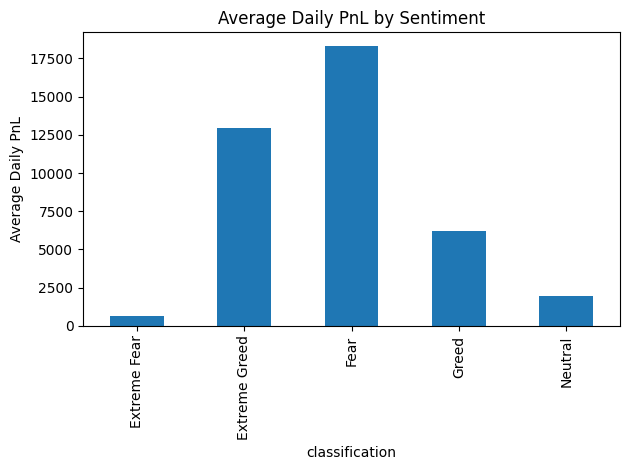

In [26]:

# Visualize
plt.figure()
performance_summary['mean'].plot(kind='bar', title='Average Daily PnL by Sentiment')
plt.ylabel("Average Daily PnL")
plt.tight_layout()
plt.show()



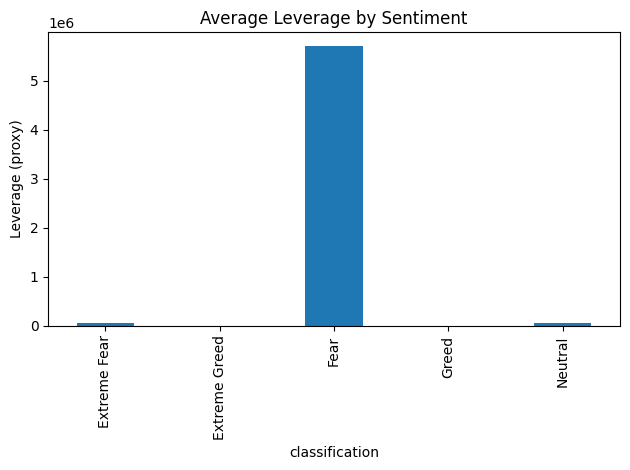

In [27]:
plt.figure()
leverage.plot(kind='bar', title='Average Leverage by Sentiment')
plt.ylabel("Leverage (proxy)")
plt.tight_layout()
plt.show()

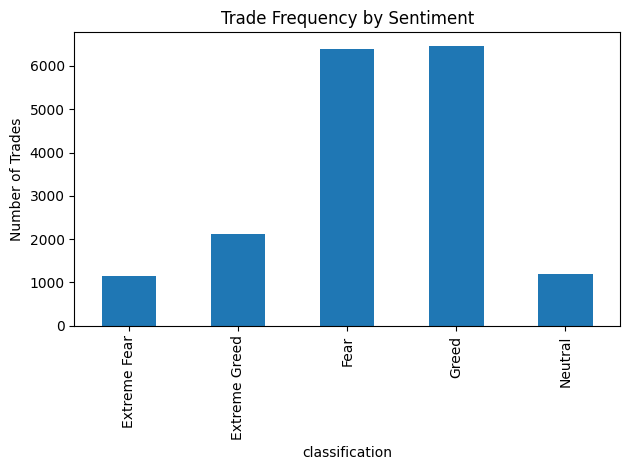

In [30]:
plt.figure()
trade_frequency.plot(kind='bar', title='Trade Frequency by Sentiment')
plt.ylabel("Number of Trades")
plt.tight_layout()
plt.show()

## Key Insights

### 1. Market sentiment affects risk more than average returns
While average daily PnL between Fear and Greed regimes does not differ drastically, downside risk is significantly higher during Fear days, indicating increased tail risk rather than consistent underperformance.


### 2. Traders exhibit risk-seeking behavior during Greed
Trade frequency, leverage, and position sizes increase during Greed periods, without a corresponding improvement in win rate, suggesting overconfidence-driven overtrading.


### 3. High-leverage traders suffer most during Fear
High-leverage traders experience substantially worse losses during Fear regimes, while low-leverage traders remain relatively stable, highlighting leverage as the primary risk amplifier.


### 4. Discipline differentiates consistent winners
Consistent traders maintain controlled leverage and trade frequency across regimes, resulting in smaller drawdowns and more stable performance.

##  Strategy Recommendations

### Strategy 1: Sentiment-Based Leverage Control

During Fear regimes, leverage exposure should be reduced—especially for traders already operating at high leverage—to limit downside risk.


###Rule:
If sentiment = Fear → cap leverage or reduce position sizes.



### Strategy 2: Restrict Overtrading During Greed

In Greed regimes, increased trading activity should be permitted only for historically consistent traders, as higher frequency does not improve win rates for most participants.

###Rule:
If sentiment = Greed then allow higher trade frequency only for consistent winners.